# Chapter 6: 学習に関するテクニック（後半 p.186〜）

## 目次

- 6.3 Batch Normalization（学習の高速化・安定化・過学習の抑制）
  - 6.3.1 Batch Normalizationのアルゴリズム
  - 6.3.2 Batch Normalizationの評価
- 6.4 正則化（過学習抑制の技術）
  - 6.4.1 過学習
  - 6.4.2 Weight decay
  - 6.4.3 Dropout
- 6.5 ハイパーパラメータの検証
  - 6.5.1 検証データ
  - 6.5.2 ハイパーパラメータの最適化
  - 6.5.3 ハイパーパラメータ最適化の実装
- 6.6 まとめ

## 6章前半の復習

6.2.2 隠れ層のアクティベーション分布
- アクティベーション ... 活性化関数の後の出力データ
- 重みの初期値によってアクティベーションがどう変化するか実験を行った

```mermaid
graph LR
    subgraph Input["入力層（1000個のデータ）"]
        G["ガウス分布で<br/>ランダム生成"]
    end
    
    subgraph Layer1["隠れ層1（100ニューロン）"]
        A1["Affine"]
        S1["Sigmoid<br/>activation[0]"]
        A1 --> S1
    end
    
    subgraph Layer2["隠れ層2（100ニューロン）"]
        A2["Affine"]
        S2["Sigmoid<br/>activation[1]"]
        A2 --> S2
    end
    
    subgraph Layer3["隠れ層3（100ニューロン）"]
        A3["Affine"]
        S3["Sigmoid<br/>activation[2]"]
        A3 --> S3
    end
    
    G --> A1
    S1 --> A2
    S2 --> A3
    S3 --> Out[ ]
    
    style G fill:#d4f1d4,color:#000
    style S1 fill:#fff4e6,color:#000
    style S2 fill:#fff4e6,color:#000
    style S3 fill:#fff4e6,color:#000
    style Out fill:none,stroke:none
```

```mermaid
graph LR
    In[ ] --> A4
    
    subgraph Layer4["隠れ層4（100ニューロン）"]
        A4["Affine"]
        S4["Sigmoid<br/>activation[3]"]
        A4 --> S4
    end
    
    subgraph Layer5["隠れ層5（100ニューロン）"]
        A5["Affine"]
        S5["Sigmoid<br/>activation[4]"]
        A5 --> S5
    end
    
    subgraph Output["出力層（10ニューロン）"]
        A6["Affine"]
        SF["Softmax"]
        A6 --> SF
    end
    
    S4 --> A5
    S5 --> A6
    SF --> Result["出力"]
    
    style In fill:none,stroke:none
    style S4 fill:#fff4e6,color:#000
    style S5 fill:#fff4e6,color:#000
    style SF fill:#ffe6e6,color:#000
    style Result fill:#e6f2ff,color:#000
```
※ イメージしやすくする為、出力層は仮定の値で設定

➡️入力層合ってるか確認、6.2.4のMNISTの方が良いか検討

重みの初期値に
- 標準偏差1のガウス分布を用いた場合：0と1に偏った分布→勾配消失が起きる
- 標準偏差0.01のガウス分布を用いた場合：表現力の制限に問題がある
- 「Xavierの初期値」を用いた場合：効率的に学習が行えそう

→ 重みの初期値を適切に設定すれば、各層のアクティベーションの分布は適切な広がりを持ち、学習がスムーズに行える

## 6.3 Batch Normalization

「6.2 重みの初期値」では、**重みの初期値を適切に設定すれば**、各層のアクティベーションの分布は適度な広がりを持ち、学習がスムーズに行えることを学んだ。それでは、**重みの初期値に執着せず強制的に**アクティベーションの分布を調整してみるとどうか？

### 6.3.1 Batch Normalizationのアルゴリズム

利点
- 学習を早く進行させることができる（学習係数を大きくすることができる）
- 重みの初期値にそれほど依存しない（初期値に対してそこまで神経質にならなくて良い）
- 過学習を抑制する（Dropoutなどの必要性を減らす）

```mermaid
flowchart LR

classDef bn fill:#e6e6e6,stroke:#000,color:#000;

subgraph Layer1
A1[Affine] --> BN1[Batch Norm] --> R1[ReLU]
end

subgraph Layer2
A2[Affine] --> BN2[Batch Norm] --> R2[ReLU]
end

subgraph Layer3
A3[Affine]
end

R1 --> A2
R2 --> A3
A3 --> SM[Softmax]

class BN1,BN2 bn;
```

Batch Normalization ... ミニバッチごとに正規化すること
- Batch(バッチ) ... まとまりのある入力データ（p.79 3.6.3 バッチ処理より）
- Normalization(正規化) ... データの分布を、平均0・分散1に変換すること

ミニバッチの入力データ $B = \{ x_1, x_2, \dots, x_m \}$ を、 \
平均0・分散1のデータ $\hat{B} = \{ \hat{x}_1, \hat{x}_2, \dots, \hat{x}_m \}$ に変換する

1. 平均 $\mu_B$ を求める
$$
\mu_B ← \frac{1}{m} \sum_{i=1}^{m} x_i
$$

2. 分散 $\sigma_B^2$ を求める
$$
\sigma_B^2 ← \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2
$$

3. 正規化（平均0、分散1に変換）
    $$
    \hat{x}_i ← \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}}
    $$
    ※ $\varepsilon$ は、小さな値（例：10e-7など）で、0での除算を防止する為のもの

4. 固有のスケール $\gamma$ とシフト $\beta$ で変換
    $$
    y_i = \gamma \hat{x}_i + \beta
    $$
    最初は $\gamma = 1$ とシフト $\beta = 0$ からスタートして、学習によって適した値に調整

参考：
- https://www.anarchive-beta.com/entry/2020/08/16/180000
- https://data-analytics.fun/2021/09/11/understanding-batch-normalization/

### 6.3.2 Batch Normalizationの評価

MNISTデータセットを使って、Batch Normレイヤを用いるときと用いないときで、学習の進みがどう変わるかをみてみる

Batch Normによって学習が速く進んでいることが分かる

#### ch06/batch_norm_test.py

重みの初期値の標準偏差をさまざまな値に変えたとき、学習がどのように変化するか

/var/folders/h6/n92v7d9d5t99qsmn8zrqpm540000gn/T/ipykernel_67365/3836009115.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


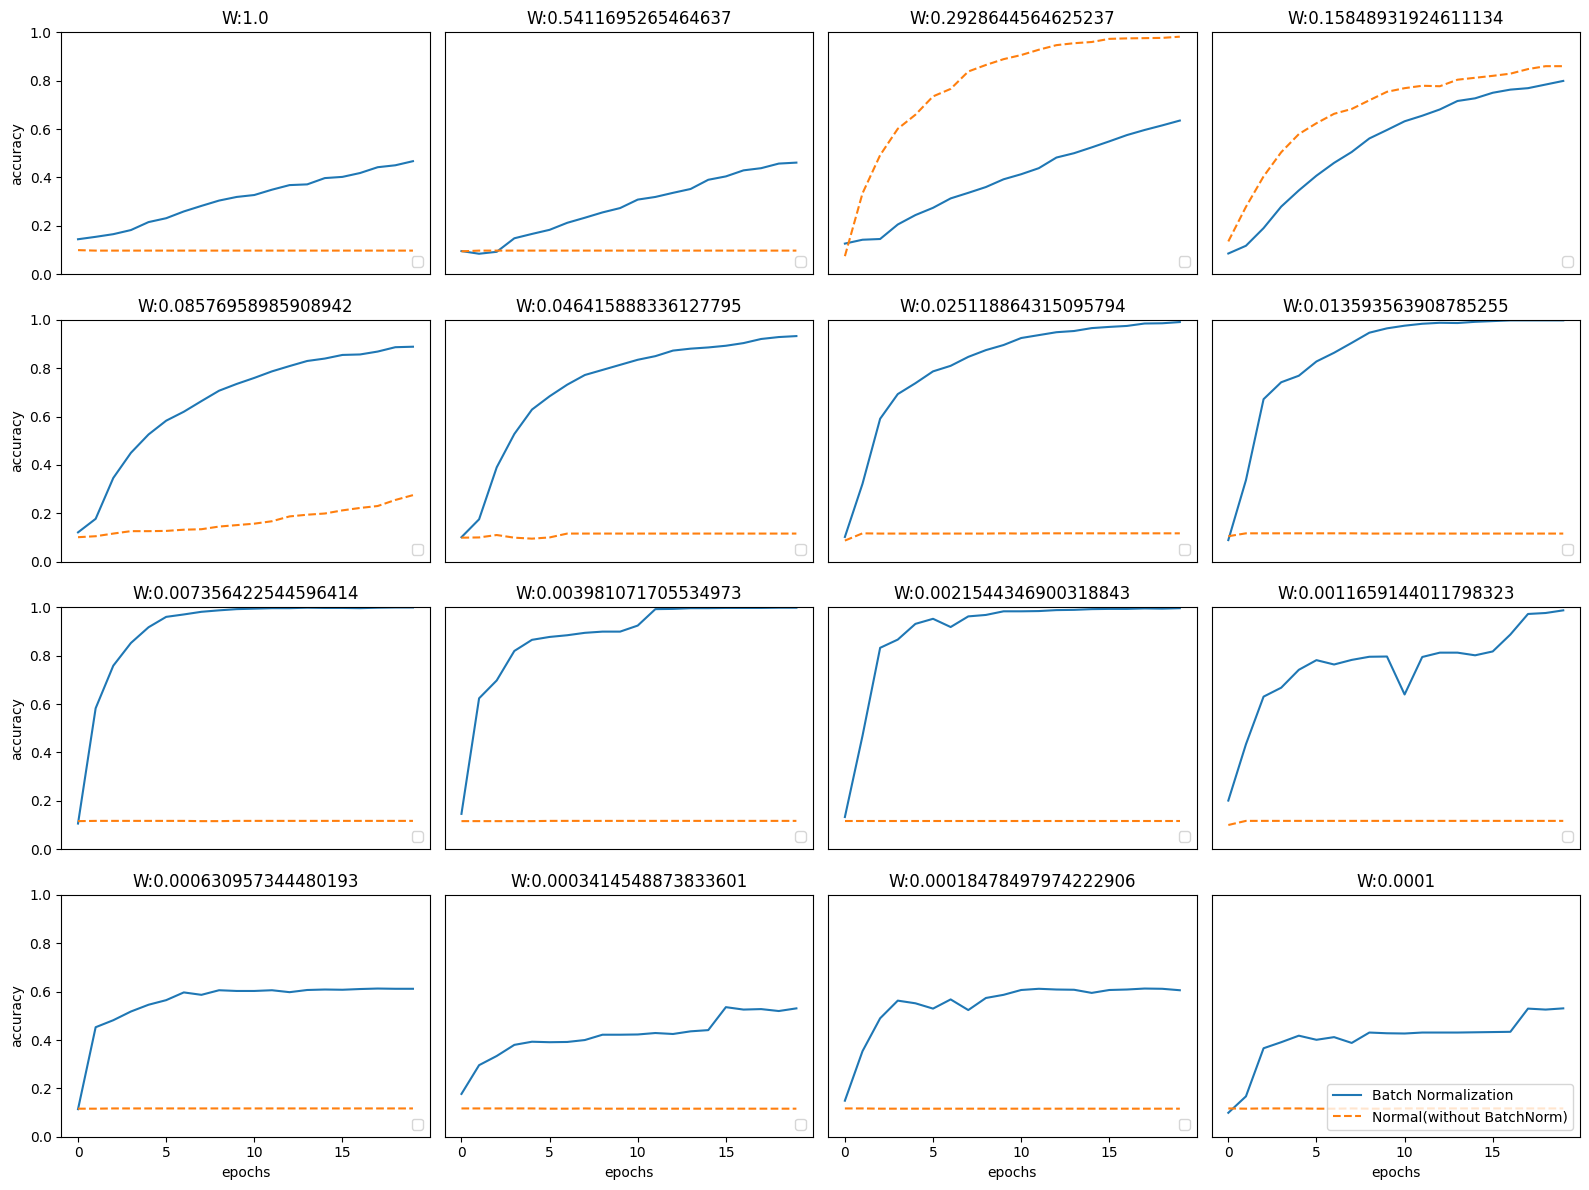

In [4]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 学習データを削減
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            # print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 3.グラフの描画==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

plt.figure(figsize=(16, 12)) # 追記

for i, w in enumerate(weight_scale_list):
    # print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)
    
    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc='lower right')
    
plt.tight_layout() # 追記
plt.show()

- 実線 ... Batch Normを使用した場合の結果
- 点線 ... Batch Normを使用しなかった場合の結果

ほとんど全てのケースでBatch Normを使用した方が学習の進みが速い
Batch Normを用いない場合は、良い初期値のスケールを与えないと、全く学習が進まない

Batch Normを使用することで、学習の進行を促進させることができ、また、重みの初期値にロバストに(それほど依存しなく)なる

## 6.4 正則化

過学習（overfitting）...  \
訓練データだけに適応しすぎてしまい、訓練データに含まれない他のデータにはうまく対応できない状態

機械学習では汎化性能の高いモデルが望まれる為、過学習を抑制するテクニックが重要になる

### 6.4.1 過学習

過学習が起きる原因
1. パラメータを大量に持ち、表現力の高いモデルであること
2. 訓練データが少ないこと

ここでは、この2つの要件をわざと満たして、過学習を発生させる
1. 7層のネットワークー各層のニューロンの個数は100個、活性化関数はReLUを使う（ネットワークの複雑性を高めるため）
2. MNISTデータセットの訓練データを本来の60,000個から300個に限定

#### ch06/overfit_weight_decay.py

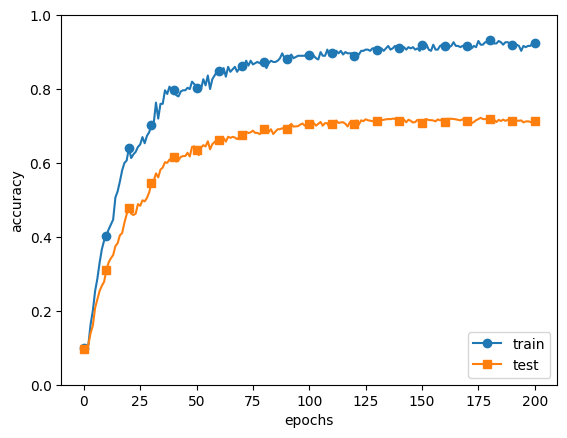

In [6]:
import os
import sys

sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（荷重減衰）の設定 =======================
#weight_decay_lambda = 0 # weight decayを使用しない場合
weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
# 以下2つには、エポック単位(全ての訓練データを見終わった単位)の認識精度が格納される
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        # print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 3.グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

- train(訓練データを用いて計測した認識精度)：100エポックを過ぎたあたりからほとんど100%
- test：100%の認識精度からは大きな隔たり←訓練データに適応し過ぎてしまった結果

➡️100%になってないから後から確認

### 6.4.2 Weight decay

過学習抑制のために昔からよく用いられる手法に「Weight decay」という手法がある

Weight decay（荷重減衰）... \
学習の過程において、大きな重みを持つことに対してペナルティを課すことで、過学習を抑制しようというもの \
※ そもそも過学習は重みパラメータが大きな値を取ることで発生することが多くある

ニューラルネットワークの学習は、損失関数（必要に応じて正則化項を含む）を最小化する問題として定式化できる

損失関数を $L(\mathbf{w})$、正則化項を $R(\mathbf{w})$ とすると、

| | 最小化問題 |
|---|---|
| **過学習対策なし** | $\min_{\mathbf{w}} L(\mathbf{w})$ |
| **正則化による過学習対策 ※** | $\min_{\mathbf{w}} \left( L(\mathbf{w}) + \lambda R(\mathbf{w}) \right)$ |

参考：https://toeming.hatenablog.com/entry/2020/04/03/000925

※ $\min_{\mathbf{w}} L(\mathbf{w})$ は、「wを変数として最小化する」の意味
> 例えば
> $$
> \min_{\mathbf{w},\,\lambda}
> \; L(\mathbf{w}) + \lambda R(\mathbf{w})
> $$
> → 「$\mathbf{w}$ と $\lambda$ の両方を動かして最小化する」の意味 \
> ※ 今回は例として出しているが、通常 λ は固定されたハイパーパラメータであり、実際の最適化は w についてのみ行う
> 
> $$
> \min_{\mathbf{w}}
> \; L(\mathbf{w}) + \lambda R(\mathbf{w})
> $$
> → 「$\lambda$ は固定して、$\mathbf{w}$ についてのみ最小化する」の意味

#### 正則化項として用いれるもの

- Lpノルム

$$
R(\mathbf{w}) = \lVert \mathbf{w} \rVert_p
= \left( \sum_{j=1}^{d} |w_j|^p \right)^{\frac{1}{p}}
$$

- Elastic Net

$$
R(\mathbf{w})
=
\alpha \lVert \mathbf{w} \rVert_1
+
(1-\alpha)\lVert \mathbf{w} \rVert_2^2
$$

- KLダイバージェンス（ベイズ的正則化）

$$
R(\mathbf{w})
=
- \log p(\mathbf{w})
$$

$$
\vdots
$$

#### Lpノルムに関して

L1ノルム(マンハッタン距離) ... 絶対値の和

$$
\lVert \mathbf{w} \rVert_1
=
\sum_{j=1}^{d} |w_j|
$$

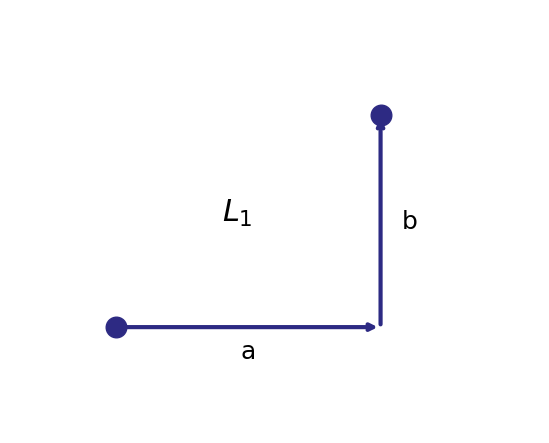

L2ノルム(ユークリッド距離) ... 各要素の2乗和 ←一般的によく用いられる

$$
\lVert \mathbf{w} \rVert_2
=
\sqrt{
\sum_{j=1}^{d} w_j^2
}
$$

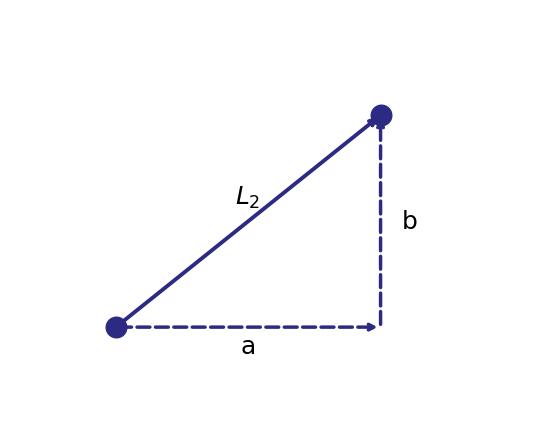

L∞ノルム(Maxノルム) ... 各要素の絶対値の中で最大のもの
$$
\lVert \mathbf{w} \rVert_\infty
=
\max_{j} |w_j|
$$

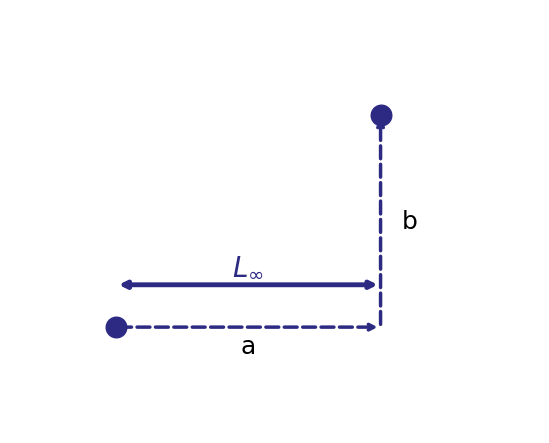

参考：https://toukei-lab.com/euclidean-manhattan-distance#L1

### 6.4.3 Dropout

Weight decay

メリット
- 簡単に実装できる
- ある程度過学習を抑制することができる

デメリット
- モデルが複雑になってくると、Weight decayだけでは対応が困難

そこで、Dropout[14]という手法がよく用いられる。Dropoutを用いれば、表現力の高いネットワークであっても、過学習を抑制することができるようになる。

Dropout ... ニューロンをランダムに消去しながら学習する手法
- 消去されたニューロンは、信号の伝達が行われなくなる（以下の図参照）
- 訓練時：データが流れるたびに、隠れ層のニューロンをランダムに選び出し、その選び出したニューロンを消去する
- テスト時：すべてのニューロンの信号を伝達するが、各ニューロンの出力に対して、(1 - dropout_ratio)を乗算して出力する
  - 例) dropout_ratio=0.2
    - 20%のニューロンを消す
    - つまり、学習は80%のニューロンで行う
    - 推論時の出力の大きさも80%に揃える


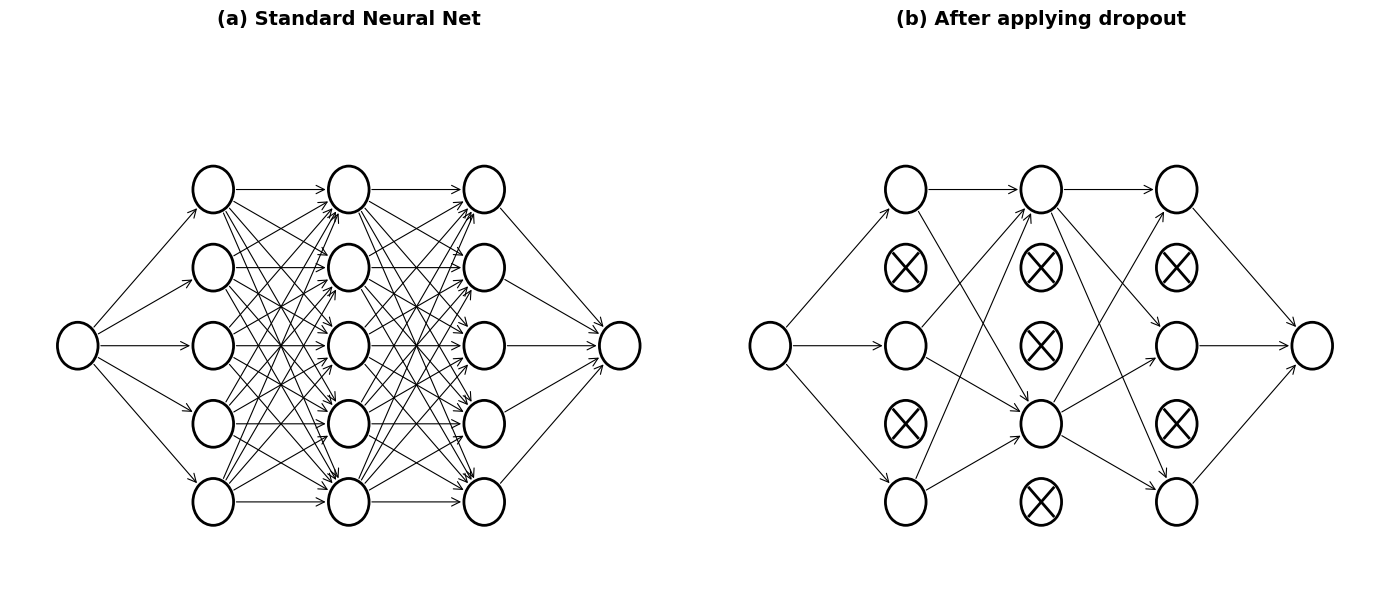

In [ ]:
class Dropout:
    def __init__(self, dropout_ratio=0.5): # 消す割合を指定
        self.dropout_ratio = dropout_ratio # 消す割合を保持
        self.mask = None # どのニューロンをマスクするかの情報を保持する変数

    def forward(self, x, train_flg=True): # train_flgは、学習時と推論時で動作を変えるためのフラグ
        if train_flg: # 学習時は、dropout_ratioの割合でニューロンをランダムに消す
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio # マスクを作成（入力と同じ形の乱数を作り、残す場所をTrueにしたマスクを作る）
            return x * self.mask # Trueの場所だけ値を残し、Falseの場所は0にする
        else: # 推論時（テスト時）
            return x * (1.0 - self.dropout_ratio) # 全てのニューロンを使用するため、出力をdropout_ratioの割合でスケーリングする

    def backward(self, dout):
        return dout * self.mask # 順伝播でマスクした場所は、逆伝播でも同じ場所を0にする

実装のポイント
- 順伝播のたびに、self.maskに消去するニューロンをFalseとして格納すること
  - self.maskは、xと同じ形状の配列をランダムに生成し、その値がdropout_ratioよりも大きい要素だけをTrueとする
- 逆伝播の挙動はReLUと同じ
  - 順伝播で信号を通したニューロンは、逆伝播の際に伝わる信号をそのまま通し、順伝播で信号を通さなかったニューロンは、逆伝播では信号がそこでストップする

#### ch06/overfit_dropout.py

MNISTデータセットで検証 \
※Trainerというクラスがネットワークの学習を行うことで、実装の簡略化を行なっている

train loss:2.306975946889085
=== epoch:1, train acc:0.10333333333333333, test acc:0.1049 ===
train loss:2.309044746734719
train loss:2.300197138914193
train loss:2.2899364208250144
=== epoch:2, train acc:0.10333333333333333, test acc:0.1078 ===
train loss:2.299351697213905
train loss:2.298579211918337
train loss:2.30033972809789
=== epoch:3, train acc:0.10333333333333333, test acc:0.1084 ===
train loss:2.298407722243274
train loss:2.290574548807106
train loss:2.2910548846749506
=== epoch:4, train acc:0.11333333333333333, test acc:0.1092 ===
train loss:2.300846571325947
train loss:2.291865408690855
train loss:2.290360587823036
=== epoch:5, train acc:0.11666666666666667, test acc:0.1106 ===
train loss:2.2935854359351695
train loss:2.2860466184842587
train loss:2.28443588064665
=== epoch:6, train acc:0.11333333333333333, test acc:0.1116 ===
train loss:2.2806688119504157
train loss:2.289689215478857
train loss:2.288062519098229
=== epoch:7, train acc:0.11, test acc:0.1132 ===
train loss:2.

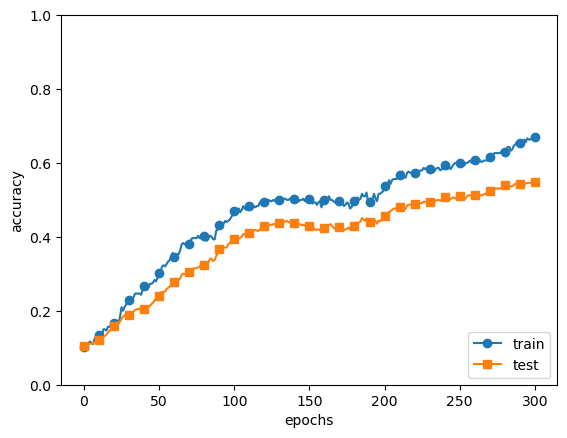

In [ ]:
import os
import sys
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.trainer import Trainer # common/trainer.pyで定義したTrainerクラスをインポート

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# Dropuoutの有無、割り合いの設定 ========================
use_dropout = True  # Dropoutなしのときの場合はFalseに
dropout_ratio = 0.2
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

**アンサンブル学習とDropoutの比較表** 

アンサンブル学習はDropoutと近い関係がある
| 項目      | アンサンブル学習                                  | Dropout                         |
| ------- | ----------------------------------------- | ------------------------------- |
| 本質的な考え方 | 複数モデルの平均で性能向上                             | 多数のサブネットワークの平均を1つのネットワークで近似     |
| 学習時     | 複数のモデルを個別に学習する                            | ニューロンをランダムに消去しながら毎回異なるモデルを学習する  |
| 推論時     | 複数モデルの出力を平均する                             | ニューロンの出力に消去割合（例：0.5）を乗算し、平均を取る  |
| 具体例     | 5つの同じ／似た構造のネットワークを学習し、テスト時は5つの出力の平均を答えとする | 1つのネットワーク内でランダムにニューロンを消去しながら学習  |
| 効果      | ニューラルネットワークの認識精度が数％向上することが分かっている                      | アンサンブル学習と同様の効果を疑似的に1つのネットワークで実現 |

## 6.5 ハイパーパラメータの検証

パラメータ
- 重みやバイアス
- ハイパーパラメータ 
  ※ 適切に設定しなければ性能が悪くなる
  - 各層のニューロンの数
  - バッチサイズ
  - パラメータの更新の際の学習係数
  - Weight decay

出来るだけ効率的にハイパーパラメータの値を探索する方法について説明する

### 6.5.1 検証データ

⚠️テストデータを使ってハイパーパラメータの性能を評価してはいけない
- 「ハイパーパラメータの性能を評価」とは、どれがどれくらい良いかを測ること
  - k=1 → 精度 85% 
  - k=3 → 精度 90%
  - k=5 → 精度 88%
- この測定値を使って、最も良いハイパーパラメータを選ぶ
- つまり、「性能評価」は「調整の一部」

理由：テストデータでハイパーパラメータを調整すると、ハイパーパラメータの値はテストデータに対して過学習を起こすことになるから

ハイパーパラメータを調整するには、ハイパーパラメータ専用の確認データ「検証データ」が必要。 \
この検証データを使って、ハイパーパラメータの良さを評価する。

データセット全体の分け方のイメージ

| データ種別 | 用途 | 割合 |
|---|---|---|
| 訓練データ（train） | パラメータ（重みやバイアス）の学習 | 60～80% |
| 検証データ（validation） | ハイパーパラメータ調整 | 10～20% |
| テストデータ（test） | 最終的な性能評価 | 10～20% |

※ 各データセットは、入力データと教師ラベルのペアで構成される

データセットによってはあらかじめ↑3つに分離されているものもある

また、訓練データとテストデータの2つに分離されているものや、分離されていないものもある→これらの場合は、自分で分離する
- MNISTデータセットの場合は、訓練データの中から20%程度を検証データとして先に分離すると簡単
  - 訓練データの分離の前に、入力データと教師ラベルをシャッフル
    - 理由：データセットによってはデータに偏りがあるかもしれないから。例えば数字が0から10まで順番に並んでいるなど。

In [7]:
import sys
import os
sys.path.append(os.pardir)
from dataset.mnist import load_mnist
from common.util import shuffle_dataset # common/util.pyで定義したshuffle_dataset関数をインポート

(x_train, t_train), (x_test, t_test) = load_mnist()

# 訓練データをシャッフル
x_train, t_train = shuffle_dataset(x_train, t_train)

# 検証データの分割
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)

x_val, t_val = x_train[:validation_num], t_train[:validation_num]
x_train, t_train = x_train[validation_num:], t_train[validation_num:]

### 6.5.2 ハイパーパラメータの最適化

ハイパーパラメータの最適化手法
| 方法 | 内容 | 効率性 | 実装難度 | 計算量 | 推奨される場面 |
|---|---|---|---|---|---|
| **グリッドサーチ** | 規則的に探索 | ⭐ 低い | ⭐ 簡単 | 指数関数 | パラメータ少数 |
| **ランダムサーチ** | ランダムに探索 | ⭐⭐ 中程度 | ⭐ 簡単 | 線形 | 基本的な探索 |
| **ベイズ最適化** | 確率論を使って効率的に探索 | ⭐⭐⭐ 高い | ⭐⭐⭐ 複雑 | 中程度 | 1試行に時間がかかる場合 |
| **ハイパーバンド** | 悪そうなパラメータを早期段階で削除 | ⭐⭐⭐ 高い | ⭐⭐ 中程度 | 低い | ディープラーニング |
| **進化戦略** | 遺伝的アルゴリズムで探索 | ⭐⭐ 中程度 | ⭐⭐ 中程度 | 中程度 | 並列化可能な場合 |
| **PSO** | 群知能で探索 | ⭐⭐ 中程度 | ⭐⭐ 中程度 | 中程度 | 連続最適化問題 |

※ copilotの生成によるもの

ニューラルネットワークのハイパーパラメータの最適化では、グリッドサーチなどの規則的な探索よりも、ランダムにサンプリングして探索する方が良い結果になることが報告されている \
➡️理由：複数あるハイパーパラメーターのうち、最終的な認識制度に与える影響度合いがハイパーパラメータごとに異なるから

グリッドサーチとランダムサーチの比較
| 項目 | グリッドサーチ | ランダムサーチ |
|---|---|---|
| **探索方法** | 等間隔で規則的に組み合わせる | ランダムにサンプリング |
| **パラメータの試行数** | 固定（例：4×4=16） | 自由（例：100回） |
| **計算コスト** | パラメータ数が増えると指数増加 | 線形増加 |
| **実装難度** | 簡単 | 比較的簡単 |
| **重要度の高いパラメータ** | 均等配置（効率悪い） | より精密に探索できる傾向 ✅ |
| **重要度の低いパラメータ** | 均等配置（無駄が多い） | 比較的少ない試行 |
| **最適値の近所を試す確率** | 低い ❌ | 高い ✅ |
| **効率性** | 低い | 高い ⭐ |

※ copilotの生成によるもの

グリッドサーチのイメージ
```plain
重み減衰 (λ)
   0.1  |  ●  ●  ●  ●
   0.01 |  ●  ●  ●  ●
  0.001 |  ●  ●  ●  ●
 0.0001 |  ●  ●  ●  ●
        +─────────────────
         0.001 0.01 0.1 1.0
              学習率 (lr)
```

ランダムサーチのイメージ
```plain
重み減衰 (λ)
   0.1  |  ●          ●
  0.05  |    ●      ●
  0.02  |      ●       ●
 0.008  |  ●             ●
 0.005  |     ●    ●
 0.002  |        ●    ●
 0.001  |  ●       ●
0.0005  |    ●        ●
        +──────────────────
         0.001 0.01  0.1  1.0
              学習率 (lr)
```

⚠️DLの学習には多くの時間が必要になる \
そのため、筋の悪そうなハイパーパラメータは早い段階で見切りをつけたく、➡️学習の為のエポックを小さくして1回の評価に要する時間を短縮するのが有効

**ランダムサーチの手順**

ポイントは、「良い値」が存在する範囲を徐々に絞り込んでいくこと

0. ハイパーパラメータの範囲を設定
    - 範囲はざっくりと指定するのが有効
    - 0.001(10^-3)から1000(10^3)ぐらいというように「10の冪乗」で指定←対数スケールと言う

1. 設定した範囲からランダムにサンプリング
2. ステップ1でサンプリングされたハイパーパラメータの値を使用して学習を行い、検証データで認識精度を評価（エポックは小さく設定）
3. ステップ1, 2をある回数（100回など）繰り返し、それらの認識精度の結果から、ハイパーパラメータの範囲を狭める

上記を繰り返し行い、範囲を絞り込む→絞り込んだ範囲からハイパーパラメータの値を1つ選び出す

↑のハイパーパラメータ最適化のアプローチは、実践的だが科学というより知恵のようなもの

より洗練された方法を求めるなら、「ベイズ最適化」がある
- ベイズの定理を中心とした数学（理論）を駆使して、より厳密に効率良く最適化を行う
- 詳しくは「Practical Bayesian Optimization of Machine Learning Algorithms」[16] を参照

### 6.5.3 ハイパーパラメータ最適化の実装

MNISTデータセットを使って、ハイパーパラメータの最適化を行う

対象の探索ハイパーパラメータ
- 学習係数（learning rate）
- Weight decay係数
  - Weight decayの強さをコントロールする係数
  
※スタンフォード大学の授業「CS231n」[5] より

#### ch06/hyperparameter_optimization.py

val acc:0.09 | lr:1.901967382287021e-06, weight decay:1.3286113794384553e-06
val acc:0.6 | lr:0.003978766790506623, weight decay:1.1494171840105422e-06
val acc:0.09 | lr:1.2638554662080983e-06, weight decay:8.29552145479523e-08
val acc:0.08 | lr:1.3645665298970673e-05, weight decay:1.6348890260392733e-06
val acc:0.1 | lr:3.376169708502469e-05, weight decay:3.6223566248485454e-06
val acc:0.2 | lr:1.054115233579305e-06, weight decay:3.6523741352877204e-06
val acc:0.09 | lr:9.484682533482772e-06, weight decay:2.7166203905198513e-08
val acc:0.19 | lr:0.0012822359991881067, weight decay:5.5083019157860015e-08
val acc:0.09 | lr:2.197396063265889e-06, weight decay:2.6199327374116732e-05
val acc:0.28 | lr:0.0028134935952994398, weight decay:9.173386087093646e-08
val acc:0.05 | lr:1.0887322819354457e-05, weight decay:5.562455484096854e-07
val acc:0.14 | lr:3.001538610842652e-05, weight decay:1.1534438081090565e-08
val acc:0.13 | lr:4.919737600309615e-06, weight decay:3.5831659974137977e-06
val 

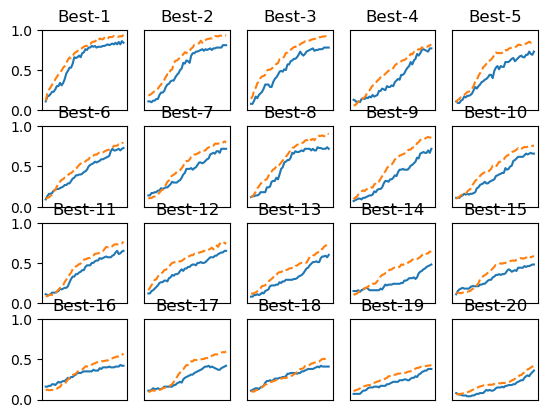

In [9]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.util import shuffle_dataset
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 高速化のため訓練データの削減
x_train = x_train[:500]
t_train = t_train[:500]

# 検証データの分離
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]


def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list


# ハイパーパラメータのランダム探索======================================
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 探索したハイパーパラメータの範囲を指定===============
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

# グラフの描画========================================================
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.show()

## 6.6 まとめ

ーーーーー

# ch06/batch_norm_gradient_check.py

In [5]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend

# データの読み込み
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100], output_size=10,
                              use_batchnorm=True)

x_batch = x_train[:1]
t_batch = t_train[:1]

grad_backprop = network.gradient(x_batch, t_batch)
grad_numerical = network.numerical_gradient(x_batch, t_batch)


for key in grad_numerical.keys():
    diff = np.average( np.abs(grad_backprop[key] - grad_numerical[key]) )
    print(key + ":" + str(diff))

W1:0.0
b1:0.0
gamma1:0.0
beta1:0.0
W2:0.0
b2:0.0
gamma2:0.0
beta2:0.05629097639991976
W3:0.0
b3:1.7990357854824612e-07
